In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Load dataset
df = pd.read_csv("olympics_athletes_dataset.csv")

# Select numerical features for clustering
features = df[['age', 'height_cm', 'weight_kg',
               'total_medals_won', 'gold_medals',
               'silver_medals', 'bronze_medals']]

# Handle missing values (if any)
features = features.fillna(features.mean())

# Feature scaling (very important for clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)


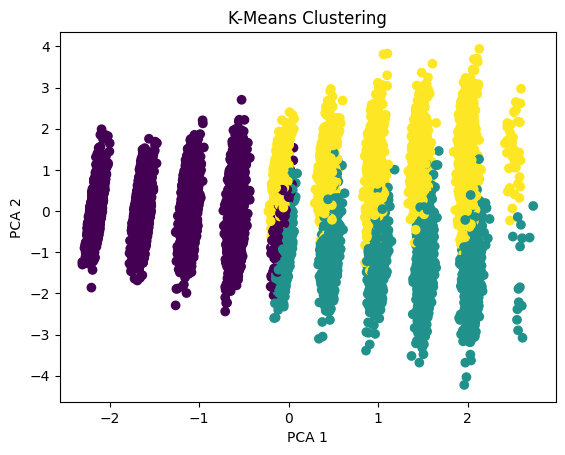

In [3]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
df['KMeans_Cluster'] = kmeans_labels

# Reduce to 2D for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

# Plot K-Means Clusters
plt.figure()
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


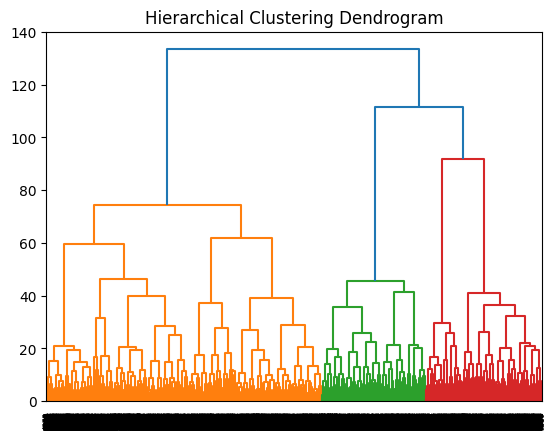

In [4]:
# Dendrogram
linked = linkage(scaled_data, method='ward')

plt.figure()
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# Apply Agglomerative Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(scaled_data)

df['Hierarchical_Cluster'] = hier_labels


In [5]:
df[['athlete_name', 'KMeans_Cluster', 'Hierarchical_Cluster']].head()


,athlete_name,KMeans_Cluster,Hierarchical_Cluster
0,Svetlana Jung,1,0
1,Mary Yamamoto,1,0
2,Oksana Volkov,0,1
3,Rui Suzuki,2,2
4,Natalya Grigoryan,0,1
